# AR(p) Parameter Estimation

The $\text{AR}(p)$ process is defined by,

$
\begin{align}
X_t = \sum_{i=1}^p \varphi_i X_{t-i} + \varepsilon_{t}
\end{align}
\tag{1}
$

where,

$
\begin{align}
\varepsilon_t \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{2}
$

The Yule-Walker equations are relate the AR(p) parameters $\varphi_i$ to the autocorrelation function. If zero mean is</br>
assumed it follows that,

$
\begin{align}
\rho_n = \frac{\text{E}[X_t X_{t-n}]}{\text{E}[X_t^2]}
\end{align}
\tag{3}
$

The autocorrelation functions can be shown to have the following properties,

$
\begin{align}
&\rho_0 = 1 \\
&\rho_n \leq 1 \\
&\rho_n = \rho_{-n}
\end{align}
\tag{4}
$

Define the matrices,

$
\begin{align}
\hat{r} =
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots \\
\rho_{n-1} \\
\rho_{n}
\end{bmatrix}
\end{align}
\tag{5}
$

$
\begin{align}
\hat{\Phi} =
\begin{bmatrix}
\varphi_1 \\
\varphi_2 \\
\varphi_3 \\
\vdots \\
\varphi_{n-1} \\
\varphi_{n}
\end{bmatrix}
\end{align}
\tag{6}
$

$
\begin{align}
\hat{R} =
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-2} & \rho_{n-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-3} & \rho_{n-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-4} & \rho_{n-3} \\
\vdots & \vdots  & \vdots & \ddots & \vdots & \vdots \\
\rho_{n-2} & \rho_{n-3} & \rho_{n-4} & \cdots & 1 & \rho_1 \\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & \rho_1 & 1 \\
\end{bmatrix}
\end{align}
\tag{7}
$

Then the Yule-Walker equations are given by,

$
\begin{align}
\hat{\Phi} = \hat{R}^{-1} \hat{r}
\end{align}
\tag{8}
$

## Examples

The Yule-Walker equations for $\text{AR}(1)$ is given by,

$
\begin{align}
\varphi_1 = \rho_1
\end{align}
\tag{9}
$

This is the OLS solution.

For $\text{AR}(2)$,

$
\begin{align}
\varphi_1 &= \frac{\rho_1 - \rho_1 \rho_2}{1 - \rho_1^2} \\
\varphi_2 &= \frac{\rho_2 - \rho_1^2}{1 - \rho_1^2}
\end{align}
\tag{10}
$

## Stationaity

Stationarity of an $\text{AR}(p)$ leads to convergence of the moments as $t \to \infty$. Recall the shift operator, $L$, defined by,

$
\begin{align}
&L X_t = X_{t-1} \\
&L^2 X_t = X_{t-2} \\
&L^3 X_t = X_{t-3} \\
&\vdots
\end{align}
\tag{11}
$

An $\text{AR}(p)$ process can be written as,

$
\begin{align}
\varepsilon_t = (1 - \varphi L - \varphi^2 L^2 - \varphi^3 L^3 - \cdots - \varphi^p L^p) X_t
\end{align}
\tag{12}
$

The characteristic equation is obtained by replacing $L$ with the variable $z$ and setting the result to zero,

$
\begin{align}
1 - \varphi z - \varphi^2 z^2 - \varphi^3 z^3 - \cdots - \varphi^p z^p = 0
\end{align}
\tag{13}
$

Stationarity requires that $\lvert z \rvert > 1$. To see this consider $\text{AR}(1)$. The characteristic equation is,

$
\begin{align}
1 - \varphi z = 0
\end{align}
\tag{14}
$

The solution is $z = \frac{1}{\varphi}$. It follows that stationarity requires,

$
\begin{align}
\lvert \varphi \rvert < 1
\end{align}
\tag{15}
$

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(φ_vals, title, ylim, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6))
    return t, scan

## Simulations

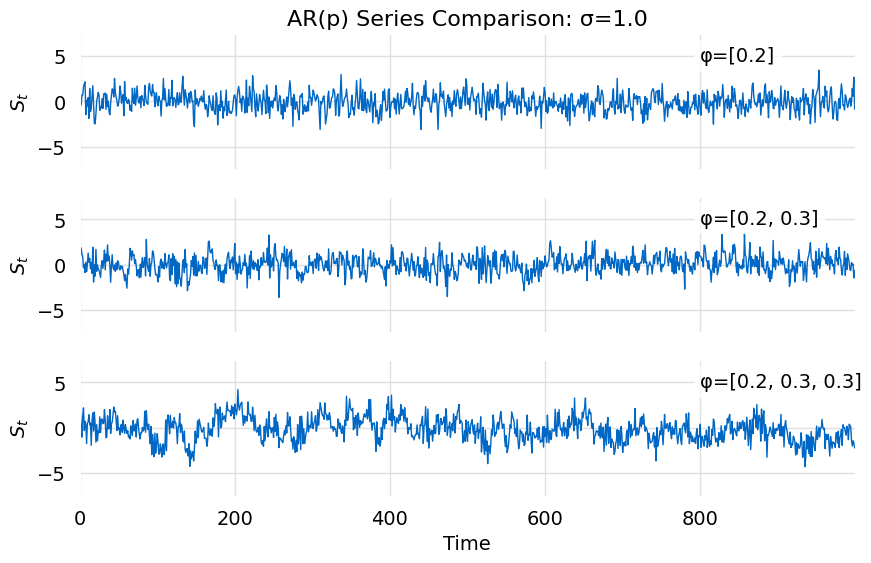

In [3]:
σ = 1.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-7.5, 7.5], *params)

## Estimation of $\text{AR}(p)$ Parameters ($\sigma = 1$)

$\text{AR}(p)$ parameters are estimated using two methods. The Yule-Walker ACF and `statsmodels.tsa.arima_model.ARMA`

### AR(1) Example $\varphi = 0.2$

In [4]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.21417427]))

In [5]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1401.300
Date:                Sun, 03 Sep 2023   AIC                           2808.600
Time:                        13:15:33   BIC                           2823.323
Sample:                             0   HQIC                          2814.196
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0586      0.040     -1.483      0.138      -0.136       0.019
ar.L1          0.2141      0.032      6.699      0.000       0.151       0.277
sigma2         0.9653      0.042     23.074      0.000       0.883       1.047
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 0.90
Prob(Q):                              0.83   Prob(JB):                         0.64
Heteroskedasticity (H):               0.90   Skew:                             0.00
Prob(H) (two-sided):                  0.35   Kurtosis:                         3.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": -0.05864314902500883,
      "err": 0.03954843261175957,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "5e8975e3-b3ed-42d0-afbb-dd9981f23182",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.21410080783567476,
         "err": 0.03195837040818093,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "5e8975e3-b3ed-42d0-afbb-dd9981f23182",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 0.9652849108427956,
      "err": 0.04183464313897079,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "5e897

### AR(2) Example $\varphi = [0.2, 0.3]$

In [7]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.14818854, 0.25569369]))

In [8]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1390.531
Date:                Sun, 03 Sep 2023   AIC                           2789.062
Time:                        13:15:33   BIC                           2808.693
Sample:                             0   HQIC                          2796.523
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0293      0.052      0.565      0.572      -0.072       0.131
ar.L1          0.1480      0.030      4.998      0.000       0.090       0.206
ar.L2          0.2564      0.030      8.552      0.000       0.198       0.315
sigma2         0.9446      0.040     23.889      0.000       0.867       1.022
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 4.66
Prob(Q):                              0.78   Prob(JB):                         0.10
Heteroskedasticity (H):               0.86   Skew:                             0.08
Prob(H) (two-sided):                  0.16   Kurtosis:                         3.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.029331553294337415,
      "err": 0.051890998454182394,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "40ed5237-66ba-48e6-a02e-fe8f327df97d",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.14803739816577843,
         "err": 0.02962101892773182,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "40ed5237-66ba-48e6-a02e-fe8f327df97d",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.2563623846005221,
         "err": 0.029978473961845213,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "

### AR(3) Example $\varphi = [0.2, 0.3, 0.3]$

In [10]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.19278515, 0.28163606, 0.31377732]))

In [11]:
result, result_model = arima.compute_ar_estimate(ar[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1428.173
Date:                Sun, 03 Sep 2023   AIC                           2866.346
Time:                        13:15:34   BIC                           2890.885
Sample:                             0   HQIC                          2875.673
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2173      0.152     -1.430      0.153      -0.515       0.081
ar.L1          0.1916      0.032      6.026      0.000       0.129       0.254
ar.L2          0.2829      0.028      9.937      0.000       0.227       0.339
ar.L3          0.3154      0.031     10.181      0.000       0.255       0.376
sigma2         1.0177      0.046     22.192      0.000       0.928       1.108
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.55
Prob(Q):                              0.91   Prob(JB):                         0.76
Heteroskedasticity (H):               0.95   Skew:                             0.06
Prob(H) (two-sided):                  0.65   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": -0.217348923865516,
      "err": 0.15199434842807732,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "1b1b8ff0-ecf0-4157-a577-c5a887a87f54",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.1916311029844417,
         "err": 0.03180126443590962,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "1b1b8ff0-ecf0-4157-a577-c5a887a87f54",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.2829195952732108,
         "err": 0.028472474255641127,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est_

## Simulations $\sigma = 5.0$

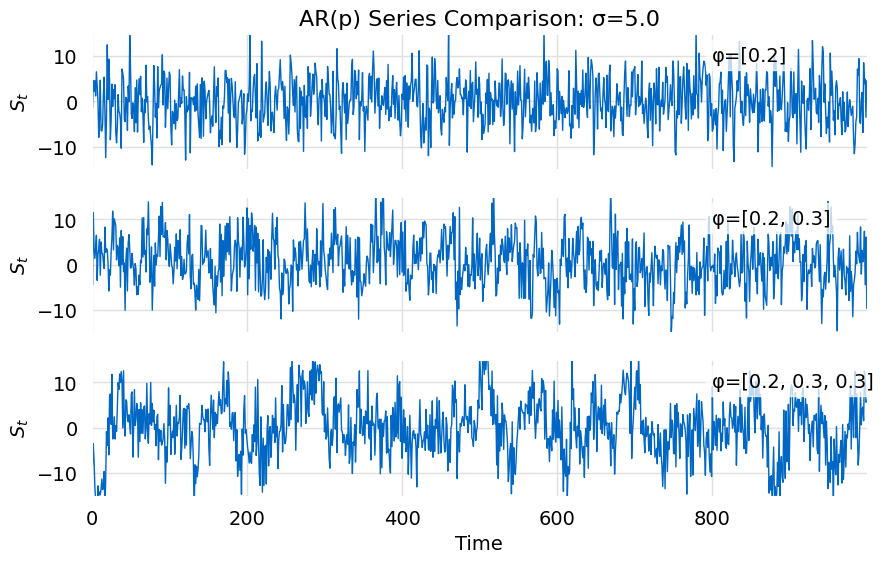

In [13]:
σ = 5.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-15.0, 15.0], *params)

### AR(1) Example ($\varphi = 0.2$)

In [14]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.16918884]))

In [15]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3037.551
Date:                Sun, 03 Sep 2023   AIC                           6081.103
Time:                        13:15:34   BIC                           6095.826
Sample:                             0   HQIC                          6086.698
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1132      0.192      0.589      0.556      -0.263       0.490
ar.L1          0.1692      0.031      5.402      0.000       0.108       0.231
sigma2        25.4619      1.145     22.237      0.000      23.218      27.706
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.27
Prob(Q):                              0.97   Prob(JB):                         0.87
Heteroskedasticity (H):               1.00   Skew:                             0.04
Prob(H) (two-sided):                  0.99   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.1131528054894351,
      "err": 0.19213382939624146,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "6a5f8970-776b-4c64-8d2e-bc8e5a2ec709",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.16915124449032168,
         "err": 0.03131214481076939,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "6a5f8970-776b-4c64-8d2e-bc8e5a2ec709",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 25.461947296615403,
      "err": 1.1450240366939919,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "6a5f8970

### AR(2) Example ($\varphi = [0.2, 0.3]$)

In [17]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.19631678, 0.2800409 ]))

In [18]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -3028.726
Date:                Sun, 03 Sep 2023   AIC                           6065.451
Time:                        13:15:34   BIC                           6085.082
Sample:                             0   HQIC                          6072.913
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7368      0.302      2.438      0.015       0.144       1.329
ar.L1          0.1959      0.030      6.596      0.000       0.138       0.254
ar.L2          0.2807      0.030      9.495      0.000       0.223       0.339
sigma2        25.0111      1.161     21.540      0.000      22.735      27.287
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.85
Prob(Q):                              0.94   Prob(JB):                         0.65
Heteroskedasticity (H):               1.20   Skew:                            -0.01
Prob(H) (two-sided):                  0.10   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.7368402046917556,
      "err": 0.30224847426191803,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "bcde0353-84f7-4bf7-90e8-981eac9e5030",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.1958917216952212,
         "err": 0.029698474548446444,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "bcde0353-84f7-4bf7-90e8-981eac9e5030",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.28071775595383536,
         "err": 0.02956365147371265,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est

### AR(3) Example ($\varphi = [0.2, 0.3, 0.3]$)

In [20]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.18559105, 0.31012709, 0.27810426]))

In [21]:
result, result_model = arima.compute_ar_estimate(ar[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -3028.685
Date:                Sun, 03 Sep 2023   AIC                           6067.370
Time:                        13:15:34   BIC                           6091.908
Sample:                             0   HQIC                          6076.696
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7367      0.305      2.415      0.016       0.139       1.335
ar.L1          0.1933      0.031      6.245      0.000       0.133       0.254
ar.L2          0.2789      0.030      9.237      0.000       0.220       0.338
ar.L3          0.0091      0.032      0.286      0.775      -0.053       0.072
sigma2        25.0094      1.162     21.531      0.000      22.733      27.286
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.83
Prob(Q):                              1.00   Prob(JB):                         0.66
Heteroskedasticity (H):               1.20   Skew:                            -0.01
Prob(H) (two-sided):                  0.10   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.7367376229403002,
      "err": 0.30500698526488446,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "41d7863c-a13b-421e-a15f-cba047784693",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.19334531647680964,
         "err": 0.03095867904977138,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "41d7863c-a13b-421e-a15f-cba047784693",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.27886037929806395,
         "err": 0.03019072997991271,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "est